In [14]:
from __Global__ import *

In [18]:
class Trends_obs_and_model():
    def run(self):
        self.plot_remote_sensing_LAI_trend()

    def plot_remote_sensing_LAI_trend(self): ## put main ms. so pdf


        fdir_trend = result_root+rf'\Upload_Data\Figure1\Spatial\LAI\\'
        temp_root = result_root + rf'\Upload_Data\Figure1\Spatial\\temp_root\\'

        outdir = result_root+rf'Upload_Data\\FIGURE\\Figure1\\'
        T.mk_dir(outdir, force=True)


        for f in os.listdir(fdir_trend):

            if not f.endswith('.tif'):
                continue
            if 'p_value' in f:
                continue


            fname = f.split('.')[0]
            fname_p_value = fname.replace('trend', 'p_value')
            print(fname_p_value)
            fpath = fdir_trend + f
            # print(fpath);exit()
            p_value_f = fdir_trend + fname_p_value+'.tif'
            print(p_value_f)
            # exit()
            plt.figure(figsize=(Plot_Robinson_remote_sensing().map_width, Plot_Robinson_remote_sensing().map_height))

            color_list = [
                '#844000',
                '#fc9831',
                '#fffbd4',
                '#86b9d2',
                '#064c6c',
            ]

            m, ret = Plot_Robinson_remote_sensing().plot_Robinson(fpath,  vmin=-1, vmax=1, is_discrete=True, colormap_n=9,color_list=color_list)

            Plot_Robinson_remote_sensing().plot_Robinson_significance_scatter(m,p_value_f,temp_root,0.05, s=0.5, marker='.')
            plt.title(f'Trends in LAI (%/yr)')
            plt.show()
            # outf = outdir + f+'.pdf'
            # plt.savefig(outf)
            # plt.close()
            # T.open_path_and_file(outdir)
            # exit()



    pass



class Plot_Robinson_remote_sensing:
    def __init__(self):
        # plt.figure(figsize=(15.3 * centimeter_factor, 8.2 * centimeter_factor))
        self.map_width = 15.3 * centimeter_factor
        self.map_height = 8.2 * centimeter_factor
        pass

    def robinson_template(self):
        '''
                :param fpath: tif file
                :param is_reproj: if True, reproject file from 4326 to Robinson
                :param res: resolution, meter
                '''

        # Blue represents high values, and red represents low values.
        plt.figure(figsize=(self.map_width, self.map_height))
        m = Basemap(projection='robin', lon_0=0, lat_0=90., resolution='c')

        # m.drawparallels(np.arange(-60., 90., 30.), zorder=99, dashes=[8, 8], linewidth=.5)
        # m.drawparallels((-90., 90.), zorder=99, dashes=[1, 0], linewidth=2)
        # meridict = m.drawmeridians(np.arange(0., 420., 60.), zorder=100, latmax=90, dashes=[8, 8], linewidth=.5)
        # meridict = m.drawmeridians((-180,180), zorder=100, latmax=90, dashes=[1, 0], linewidth=2)
        # for obj in meridict:
        #     line = meridict[obj][0][0]
        # coastlines = m.drawcoastlines(zorder=100, linewidth=0.2)
        # polys = m.fillcontinents(color='#FFFFFF', lake_color='#EFEFEF', zorder=90)
    def plot_Robinson_significance_scatter(self, m, fpath_p, temp_root, sig_level=0.05, ax=None, linewidths=0.5, s=20,
                                           c='k', marker='x',
                                           zorder=100, res=2):

        fpath_clip = fpath_p + 'clip.tif'
        fpath_spatial_dict = DIC_and_TIF(tif_template=fpath_p).spatial_tif_to_dic(fpath_p)
        D_clip = DIC_and_TIF(tif_template=fpath_p)
        D_clip_lon_lat_pix_dict = D_clip.spatial_tif_to_lon_lat_dic(temp_root)
        fpath_clip_spatial_dict_clipped = {}
        for pix in fpath_spatial_dict:
            lon, lat = D_clip_lon_lat_pix_dict[pix]
            fpath_clip_spatial_dict_clipped[pix] = fpath_spatial_dict[pix]
        DIC_and_TIF(tif_template=fpath_p).pix_dic_to_tif(fpath_clip_spatial_dict_clipped, fpath_clip)
        fpath_resample = fpath_clip + 'resample.tif'
        ToRaster().resample_reproj(fpath_clip, fpath_resample, res=res)
        fpath_resample_ortho = fpath_resample + 'Robinson.tif'
        self.Robinson_reproj(fpath_resample, fpath_resample_ortho, res=res * 10000)
        arr, originX, originY, pixelWidth, pixelHeight = ToRaster().raster2array(fpath_resample)
        # lon_list = np.arange(originX, originX + pixelWidth * arr.shape[1], pixelWidth)
        # lat_list = np.arange(originY, originY + pixelHeight * arr.shape[0], pixelHeight)
        # arr_reproj, originX_reproj, originY_reproj, pixelWidth_reproj, pixelHeight_reproj = ToRaster().raster2array(fpath_resample_ortho)
        # lon_list_reproj = np.arange(originX_reproj, originX_reproj + pixelWidth_reproj * arr_reproj.shape[1], pixelWidth_reproj)
        # lat_list_reproj = np.arange(originY_reproj, originY_reproj + pixelHeight_reproj * arr_reproj.shape[0], pixelHeight_reproj)
        # arr = m.transform_scalar(arr, lon_list, lat_list[::-1], len(lon_list_reproj), len(lat_list_reproj))
        arr = Tools().mask_999999_arr(arr, warning=False)
        arr[arr > sig_level] = np.nan
        # plt.figure()
        # plt.imshow(arr,interpolation='nearest',cmap='jet')
        # plt.show()
        D_resample = DIC_and_TIF(tif_template=fpath_resample)
        #
        os.remove(fpath_clip)
        os.remove(fpath_resample_ortho)
        os.remove(fpath_resample)

        spatial_dict = D_resample.spatial_arr_to_dic(arr)
        lon_lat_pix_dict = D_resample.spatial_tif_to_lon_lat_dic(temp_root)
        # keys = spatial_dict.keys()

        lon_list = []
        lat_list = []
        for pix in spatial_dict:
            val = spatial_dict[pix]
            if np.isnan(val):
                continue
            lon, lat = lon_lat_pix_dict[pix]
            lon_list.append(lon)
            lat_list.append(lat)
        lon_list = np.array(lon_list)
        lat_list = np.array(lat_list)
        # lon_list = lon_list - originX
        # lat_list = lat_list + originY
        lon_list = lon_list + pixelWidth / 2
        lat_list = lat_list + pixelHeight / 2
        # print(lon_list)
        # m,ret = Plot().plot_ortho(fpath,vmin=-0.5,vmax=0.5)
        m.scatter(lon_list, lat_list, latlon=True, s=s, c=c, zorder=zorder, marker=marker, ax=ax,
                  linewidths=linewidths)

        return m


    def plot_Robinson(self, fpath, ax=None, cmap=None, vmin=None, vmax=None, is_plot_colorbar=True, is_reproj=True,
                      res=25000, is_discrete=False, colormap_n=11,color_list=None):
        '''
        :param fpath: tif file
        :param is_reproj: if True, reproject file from 4326 to Robinson
        :param res: resolution, meter
        ## trend color list
        '''


        # std_list=[ '#e66101',
        #            '#fdb863',
        #            '#f7f7f7',
        #            '#b2abd2',
        #            '#5e3c99',
        #
        # ]

        # Blue represents high values, and red represents low values.
        if ax == None:
            # plt.figure(figsize=(10, 10))
            ax = plt.subplot(1, 1, 1)
        if cmap is None:
            cmap = Tools().cmap_blend(color_list)
        elif type(cmap) == str:
            cmap = plt.get_cmap(cmap)
        arr, originX, originY, pixelWidth, pixelHeight = ToRaster().raster2array(fpath)
        lon_list = np.arange(originX, originX + pixelWidth * arr.shape[1], pixelWidth)
        lat_list = np.arange(originY, originY + pixelHeight * arr.shape[0], pixelHeight)
        # print(np.shape(arr))
        # plt.imshow(arr)
        # plt.show()
        if not is_reproj:
            arr_reproj, originX, originY, pixelWidth, pixelHeight = ToRaster().raster2array(fpath)
            lon_list_reproj = np.arange(originX, originX + pixelWidth * arr.shape[1], pixelWidth)
            lat_list_reproj = np.arange(originY, originY + pixelHeight * arr.shape[0], pixelHeight)
        else:
            fpath_robinson = self.Robinson_reproj(fpath, fpath + '_robinson-reproj.tif', res=res)
            arr_reproj, originX, originY, pixelWidth, pixelHeight = ToRaster().raster2array(fpath_robinson)
            lon_list_reproj = np.arange(originX, originX + pixelWidth * arr.shape[1], pixelWidth)
            lat_list_reproj = np.arange(originY, originY + pixelHeight * arr.shape[0], pixelHeight)
            # print(originX, originY, pixelWidth, pixelHeight)
            arr_reproj[arr_reproj<-9999] = np.nan
            # plt.imshow(arr_reproj,interpolation='nearest')
            # plt.show()
            os.remove(fpath_robinson)
            # print(fpath_robinson)
            # exit()
        # originY1 = copy.copy(originY)
        arr = Tools().mask_999999_arr(arr, warning=False)
        arr_m = ma.masked_where(np.isnan(arr), arr)
        # originX = 0
        # originY = originY * 2
        # originY = 0

        # lon_list, lat_list = np.meshgrid(lon_list, lat_list)
        # print(lon_list.shape)
        # plt.imshow(arr_m)
        # plt.show()
        # exit()
        m = Basemap(projection='robin', lon_0=0, lat_0=90., ax=ax, resolution='c')
        # print(lon_list)
        # print(lat_list)
        # m = Basemap(projection='robin', lon_0=0,ax=ax, resolution='c')
        arr_m = m.transform_scalar(arr_m,lon_list,lat_list[::-1],len(lon_list_reproj)*1,len(lat_list_reproj)*1,order=0)
        # m.transform_vector()
        # plt.imshow(arr_m,interpolation='nearest')
        # plt.show()

        ret = m.pcolormesh(lon_list, lat_list, arr_m, cmap=cmap, zorder=99, vmin=vmin, vmax=vmax, )
        ret = m.imshow(arr_m[::-1], cmap=cmap, zorder=99, vmin=vmin, vmax=vmax,interpolation='nearest')
        # m.drawparallels(np.arange(-60., 90., 30.), zorder=99, dashes=[8, 8], linewidth=.5)
        # m.drawparallels((-90., 90.), zorder=99, dashes=[1, 0], linewidth=2)
        # plt.show()
        # meridict = m.drawmeridians(np.arange(0., 420., 60.), zorder=100, latmax=90, dashes=[8, 8], linewidth=.5)
        # meridict = m.drawmeridians((-180,180), zorder=100, latmax=90, dashes=[1, 0], linewidth=2)
        # for obj in meridict:
        #     line = meridict[obj][0][0]
        # coastlines = m.drawcoastlines(zorder=100, linewidth=0.2)
        # polys = m.fillcontinents(color='whitesmoke', lake_color='#EFEFEF', zorder=90)
        # plt.show()
        if is_plot_colorbar:
            if is_discrete:
                bounds = np.linspace(vmin, vmax, colormap_n)
                # norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')
                norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
                cax, kw = mpl.colorbar.make_axes(ax, location='bottom', pad=0.05, shrink=0.5)
                cbar = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, boundaries=bounds, ticks=bounds,
                                                 orientation='horizontal')
            else:
                cbar = plt.colorbar(ret, ax=ax, shrink=0.5, location='bottom', pad=0.05)
        return m, ret

    def Robinson_reproj(self, fpath, outf, res=50000):
        wkt = self.Robinson_wkt()
        srs = DIC_and_TIF().gen_srs_from_wkt(wkt)
        ToRaster().resample_reproj(fpath, outf, res, dstSRS=srs)
        return outf

    def Robinson_wkt(self):
        wkt = '''
        PROJCRS["Sphere_Robinson",
    BASEGEOGCRS["Unknown datum based upon the Authalic Sphere",
        DATUM["Not specified (based on Authalic Sphere)",
            ELLIPSOID["Sphere",6371000,0,
                LENGTHUNIT["metre",1]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["Degree",0.0174532925199433]]],
    CONVERSION["Sphere_Robinson",
        METHOD["Robinson"],
        PARAMETER["Longitude of natural origin",0,
            ANGLEUNIT["Degree",0.0174532925199433],
            ID["EPSG",8802]],
        PARAMETER["False easting",0,
            LENGTHUNIT["metre",1],
            ID["EPSG",8806]],
        PARAMETER["False northing",0,
            LENGTHUNIT["metre",1],
            ID["EPSG",8807]]],
    CS[Cartesian,2],
        AXIS["(E)",east,
            ORDER[1],
            LENGTHUNIT["metre",1]],
        AXIS["(N)",north,
            ORDER[2],
            LENGTHUNIT["metre",1]],
    USAGE[
        SCOPE["Not known."],
        AREA["World."],
        BBOX[-90,-180,90,180]],
    ID["ESRI",53030]]'''
        return wkt


class Trends_CV_obs_and_model():
    def __init__(self):
        pass
    def run(self):
        self.plot_remote_sensing_CV()


    def plot_remote_sensing_CV(self): ## put main ms. so pdf


        fdir_trend = result_root+rf'\Upload_Data\Figure1\Spatial\\CVLAI\\'
        temp_root=result_root+rf'\Upload_Data\Figure1\Spatial\\temp_root\\'
        T.mkdir(temp_root,force=True)

        outdir = result_root+rf'Upload_Data\\FIGURE\\Figure1b\\'
        T.mk_dir(outdir, force=True)


        for f in os.listdir(fdir_trend):

            if not f.endswith('.tif'):
                continue
            if 'p_value' in f:
                continue



            f_trend = result_root+rf'\Upload_Data\Figure1\Spatial\CVLAI\\composite_LAI_mean_detrend_CV_trend.tif'
            # print(fpath);exit()
            p_value_f =result_root+rf'\Upload_Data\Figure1\Spatial\CVLAI\\composite_LAI_mean_detrend_CV_p_value.tif'
            print(p_value_f)


            color_list = [
                '#008837',
                '#a6dba0',
                '#f7f7f7',
                '#c2a5cf',
                '#7b3294',
            ]



            # exit()
            plt.figure(figsize=(Plot_Robinson_remote_sensing().map_width, Plot_Robinson_remote_sensing().map_height))
            m, ret = Plot_Robinson_remote_sensing().plot_Robinson(f_trend, vmin=-1, vmax=1, is_discrete=True, colormap_n=9,color_list=color_list, )

            Plot_Robinson_remote_sensing().plot_Robinson_significance_scatter(m,p_value_f,temp_root,0.05, s=0.5, marker='.')
            plt.title('Trends in LAIcv')
            plt.show()

            # outf = outdir + f+'.pdf'
            # plt.savefig(outf)
            # plt.close()
            # T.open_path_and_file(outdir)
            # exit()


    pass



class plot_time_series:
    def __init__(self):
        self.map_width = 13 * centimeter_factor
        self.map_height = 8.2 * centimeter_factor
        pass
    def run(self):
        # self.plot_relative_change_LAI()
        self.plot_CV_LAI()
        pass

    def plot_relative_change_LAI(self):  ##### plot for 4 clusters

        df = T.load_df(
            result_root + rf'\Upload_Data\Figure1\time_series\\relative_change_area_weighted.df')
        # print(len(df))
        df = self.df_clean(df)

        # print(len(df))
        # T.print_head_n(df)
        # exit()

        # create color list with one green and another 14 are grey

        color_list = ['black','green', 'blue',  'magenta', 'black','purple',  'purple', 'black', 'yellow', 'purple', 'pink', 'grey',
                      'brown', 'lime', 'teal', 'magenta']
        linewidth_list = [2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]





        # variable_list = ['LAI4g', 'AVHRR_solely_relative_change','GEODES_AVHRR_LAI_relative_change',]
        # variable_list = ['NDVI', 'NDVI4g', 'GIMMS_plus_NDVI', ]
        #'detrended_SNU_LAI_CV','SNU_LAI_predict_detrend_CV','

        variable_list = [
                         'composite_LAI_mean','LAI4g', 'SNU_LAI',
            'GLOBMAP_LAI',
                         ]
        dic_label={'LAI4g':'LAI4g','SNU_LAI':'SNU_LAI',
                   'GLOBMAP_LAI':'GLOBMAP_LAI',
                   'composite_LAI_mean':'Composite LAI'}
        year_list=range(1982,2021)

        result_dic = {}

        for var in variable_list:
            mean_dic = {}
            for year in year_list:
                df_i = df[df['year'] == year]
                ## scheme1
                vals = np.array(df_i[f'{var}_relative_change'].tolist(), dtype=float)
                weight = np.array(df_i['area_weight'].tolist(), dtype=float)
                weighted_mean_values = (
                        np.nansum(vals * weight)
                        / np.nansum(weight * np.isfinite(vals))
                )

                # print(var, year, weighted_mean_values)
                ## scheme2
                # vals = np.array(df_i[f'{var}_relative_change'].tolist(), dtype=float)
                # weighted_mean_values = np.nanmean(vals)

                mean_dic[year] = weighted_mean_values

            result_dic[var] = mean_dic


        # convert to DataFrame
        df_new = pd.DataFrame(result_dic).reset_index()



        # T.print_head_n(df_new);exit()


        flag=0
        plt.figure(figsize=(self.map_width, self.map_height))

        for var in variable_list:
            plt.plot(year_list, df_new[var], label=dic_label[var],linewidth=linewidth_list[flag], color=color_list[flag])
            flag=flag+1
            slope, intercept, r_value, p_value, std_err = stats.linregress(year_list, df_new[var])
            # print(var, f'{slope:.2f}', f'{p_value:.2f}')
        plt.ylabel('Relative change LAI (%)')

        plt.grid(True, axis='x')   # 只画竖线（随 x 刻度）

        plt.legend()
        plt.show()
        # out_pdf_fdir = result_root + rf'\Figure\\weighted_area\\Figure1a\\'
        # T.mk_dir(out_pdf_fdir, force=True)
        # plt.savefig(out_pdf_fdir + 'time_series_relative_change_mean.pdf', dpi=300, bbox_inches='tight')
        # plt.close()


    def plot_CV_LAI(self):  ##### plot for 4 clusters

        df = T.load_df(
            result_root + rf'\Upload_Data\Figure1\time_series\\CVLAI_area_weighted.df')
        # print(len(df))
        df = self.df_clean(df)

        # print(len(df))
        # T.print_head_n(df)
        # exit()

        # create color list with one green and another 14 are grey

        color_list = ['black', 'green', 'blue', 'magenta', 'black', 'purple', 'purple', 'black', 'yellow', 'purple',
                      'pink', 'grey',
                      'brown', 'lime', 'teal', 'magenta']
        linewidth_list = [2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

        variable_list = ['composite_LAI_mean',
                         'LAI4g', 'SNU_LAI',
                         'GLOBMAP_LAI', ]
        dic_label = {'composite_LAI_mean': 'Composite LAI',
                     'LAI4g': 'GIMMS4g',

                     'GLOBMAP_LAI': 'GLOBMAP',
                     'SNU_LAI': 'SNU', }
        year_list = range(0, 25)

        result_dic = {}

        for var in variable_list:
            mean_dic={}
            for year in year_list:
                df_i = df[df['window'] == year]
                ## scheme1
                vals = np.array(df_i[f'{var}_detrend_CV'].tolist(), dtype=float)
                weight=np.array(df_i['area_weight'].tolist(),dtype=float)
                weighted_mean_values = (
                        np.nansum(vals * weight)
                        / np.nansum(weight * np.isfinite(vals))
                )
                # print(year,weighted_mean_values)
                ## scheme2
                # vals = np.array(df_i[f'{var}_detrend_CV_area_weighted'].tolist(), dtype=float)
                # weighted_mean_values = np.nanmean(vals)

                mean_dic[year] = weighted_mean_values

            result_dic[var] = mean_dic


        # 转成 DataFrame
        df_new = pd.DataFrame(result_dic).reset_index()
        # T.print_head_n(df_new);exit()

        flag = 0

        plt.figure(figsize=(self.map_width, self.map_height))

        for var in variable_list:
            plt.plot(
                year_list,
                df_new[var],
                label=dic_label[var],
                linewidth=linewidth_list[flag],
                color=color_list[flag]
            )

            slope, intercept, r_value, p_value, std_err = stats.linregress(year_list, df_new[var])
            # print(var, f'{slope:.2f}', f'{p_value:.2f}')

            ## std

            flag = flag + 1
        ## if var == 'composite_LAI_CV': plot CI bar

        window_size = 15

        # set xticks with 1982-1997, 1998-2013,.. 2014-2020
        year_range = range(1982, 2021)
        year_range_str = []
        for year in year_range:

            start_year = year
            end_year = year + window_size - 1
            if end_year > 2021:
                break
            year_range_str.append(f'{start_year}-{end_year}')

        plt.xticks(range(len(year_range_str))[::3], year_range_str[::3], rotation=45, ha='right')
        plt.yticks(np.arange(5, 25, 5))

        plt.ylabel(f'CVLAI (%/yr)')
        plt.grid(True, axis='x')  # 只画竖线（随 x 刻度）

        plt.legend(loc='upper left')

        plt.show()
        # plt.tight_layout()
        # out_pdf_fdir = result_root + rf'\FIGURE\weighted_area\\'
        # T.mk_dir(out_pdf_fdir, force=True)
        # plt.savefig(out_pdf_fdir + 'time_series_CV_mean.pdf', dpi=300, bbox_inches='tight')
        # plt.close()

        #
        # plt.legend()
        # plt.show()
    def df_clean(self, df):
        # T.print_head_n(df)
        # df = df.dropna(subset=[self.y_variable])
        # T.print_head_n(df)
        # exit()
        df = df[df['row'] > 60]
        df = df[df['Aridity'] < 0.65]
        df = df[df['LC_max'] < 10]
        df = df[df['MODIS_LUCC'] != 12]

        df = df[df['landcover_classfication'] != 'Cropland']

        return df

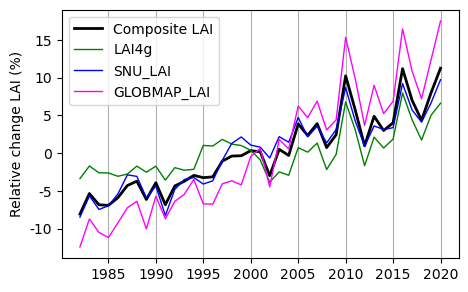

In [19]:
plot_time_series().plot_relative_change_LAI()  ## Figure 1 a

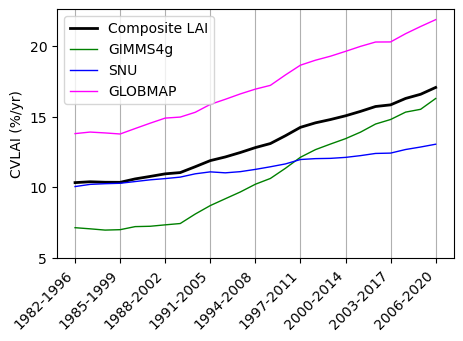

In [20]:
plot_time_series().plot_CV_LAI()  ## Figure 1 c

composite_LAI_mean_relative_change_p_value
D:/Project3/Result/Nov//\Upload_Data\Figure1\Spatial\LAI\\composite_LAI_mean_relative_change_p_value.tif
loading D:/Project3/Result/Nov//\Upload_Data\Figure1\Spatial\\temp_root\\DIC_and_TIF\54da65351b23ba7eda340d9a0600bea24c4a143680d4079bbe98d8d83c4a195c.npy
loading D:/Project3/Result/Nov//\Upload_Data\Figure1\Spatial\\temp_root\\DIC_and_TIF\da1907172278b905cd55488f5379ba8bb160c366df0dbaa45df1be0cc22a6f36.npy


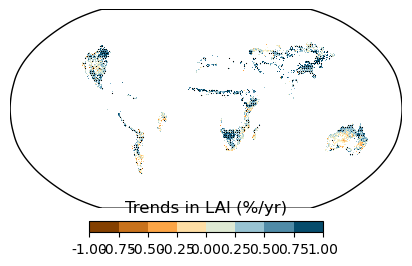

In [21]:
Trends_obs_and_model().run()  ## Figure 1 b

D:/Project3/Result/Nov//\Upload_Data\Figure1\Spatial\CVLAI\\composite_LAI_mean_detrend_CV_p_value.tif
loading D:/Project3/Result/Nov//\Upload_Data\Figure1\Spatial\\temp_root\\DIC_and_TIF\54da65351b23ba7eda340d9a0600bea24c4a143680d4079bbe98d8d83c4a195c.npy
loading D:/Project3/Result/Nov//\Upload_Data\Figure1\Spatial\\temp_root\\DIC_and_TIF\da1907172278b905cd55488f5379ba8bb160c366df0dbaa45df1be0cc22a6f36.npy


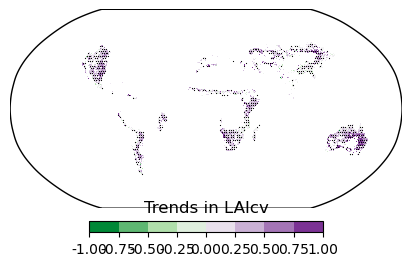

In [22]:
Trends_CV_obs_and_model().run() ## Figure 1 d